# Physics Integrator Benchmark — Analysis & Visualisation

Analyses two CSV files produced by the benchmark:
- **`benchmark.csv`** — aggregated metrics per (solver, dt)
- **`energy_drift.csv`** — E(t) time series for selected dt values

Plots produced:
1. Contact time error vs dt (log-log) — convergence order
2. Max energy drift vs dt (log-log)
3. Cost vs precision (ops_total vs contact_error, log-log)
4. CPU time vs dt
5. E(t) time series per solver and dt
6. Summary statistics table

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# Load data

In [2]:
BENCHMARK_CSV    = Path("benchmark.csv")
ENERGY_DRIFT_CSV = Path("energy_drift.csv")

df  = pd.read_csv(BENCHMARK_CSV)
ede = pd.read_csv(ENERGY_DRIFT_CSV)

# Drop rows where contact was never reached (NaN error means solver diverged)
df_valid = df.dropna(subset=["contact_error"]).copy()

print(f"benchmark.csv    : {len(df)} rows  ({df['solver'].nunique()} solvers, {df['dt'].nunique()} dt values)")
print(f"energy_drift.csv : {len(ede)} rows")
df.head()

benchmark.csv    : 150 rows  (3 solvers, 50 dt values)
energy_drift.csv : 6378 rows


,solver,dt,contact_error,max_energy_drift,final_energy_drift,cpu_ms,ops_total
0,Euler,0.500000,NaN,0.244627,0.244627,12,4
1,Euler,0.400934,NaN,0.157293,0.157293,3,4
2,Euler,0.321496,NaN,0.151707,0.151707,4,6
3,Euler,0.257797,0.118817,1.000000,1.000000,7,7
4,Euler,0.206719,NaN,0.094082,0.094082,6,9


# Style helpers

In [3]:
SOLVER_STYLE = {
    "Euler":  {"color": "#E24B4A", "marker": "o", "ls": "-"},
    "Verlet": {"color": "#378ADD", "marker": "s", "ls": "--"},
    "RK4":    {"color": "#1D9E75", "marker": "^", "ls": "-."},
}

def solver_legend(ax):
    handles = [
        Line2D([0], [0], color=s["color"], marker=s["marker"],
               linestyle=s["ls"], label=name, markersize=6)
        for name, s in SOLVER_STYLE.items()
    ]
    ax.legend(handles=handles, framealpha=0.4)

# Plot 1: Contact time error vs dt  (convergence order)

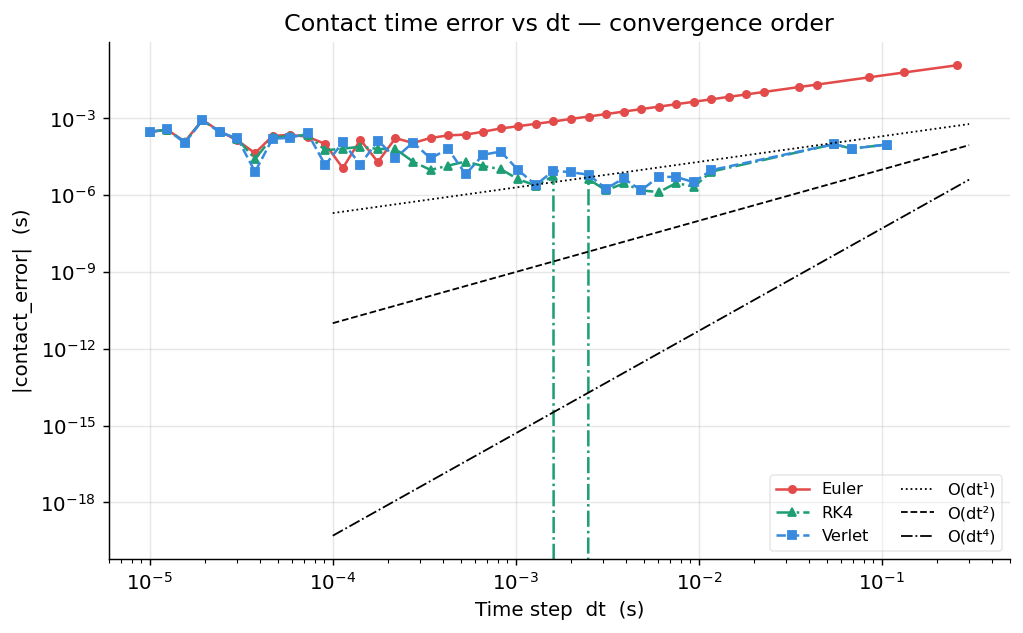

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

for solver, grp in df_valid.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")
    ax.loglog(grp["dt"], grp["contact_error"],
              color=s["color"], marker=s["marker"], ls=s["ls"],
              markersize=4, linewidth=1.4, label=solver)

# Reference slopes
dt_ref = np.array([1e-4, 3e-1])
ax.loglog(dt_ref, 2e-3 * dt_ref**1, "k:",  linewidth=1, label="O(dt¹)")
ax.loglog(dt_ref, 1e-3 * dt_ref**2, "k--", linewidth=1, label="O(dt²)")
ax.loglog(dt_ref, 5e-4 * dt_ref**4, "k-.", linewidth=1, label="O(dt⁴)")

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("|contact_error|  (s)")
ax.set_title("Contact time error vs dt — convergence order")
ax.legend(ncol=2, framealpha=0.4, fontsize=9)
plt.tight_layout()
plt.savefig("plot_convergence.png", dpi=150)
plt.show()

# Estimated convergence order (linear regression on log-log)

In [5]:
print(f"{'Solver':<10} {'Estimated order':>16} {'R²':>8}")
print("-" * 38)

for solver, grp in df_valid.groupby("solver"):
    grp = grp.sort_values("dt")
    # Keep only rows where error > 0 (avoid log(0))
    mask = grp["contact_error"] > 0
    if mask.sum() < 3:
        print(f"{solver:<10} {'not enough valid points':>16}")
        continue
    log_dt  = np.log10(grp.loc[mask, "dt"])
    log_err = np.log10(grp.loc[mask, "contact_error"])
    slope, intercept, r, *_ = stats.linregress(log_dt, log_err)
    print(f"{solver:<10} {slope:>16.3f} {r**2:>8.4f}")

Solver      Estimated order       R²
--------------------------------------
Euler                 0.669   0.7510
RK4                  -0.438   0.3669
Verlet               -0.374   0.3040


# Plot 2: Max energy drift vs dt

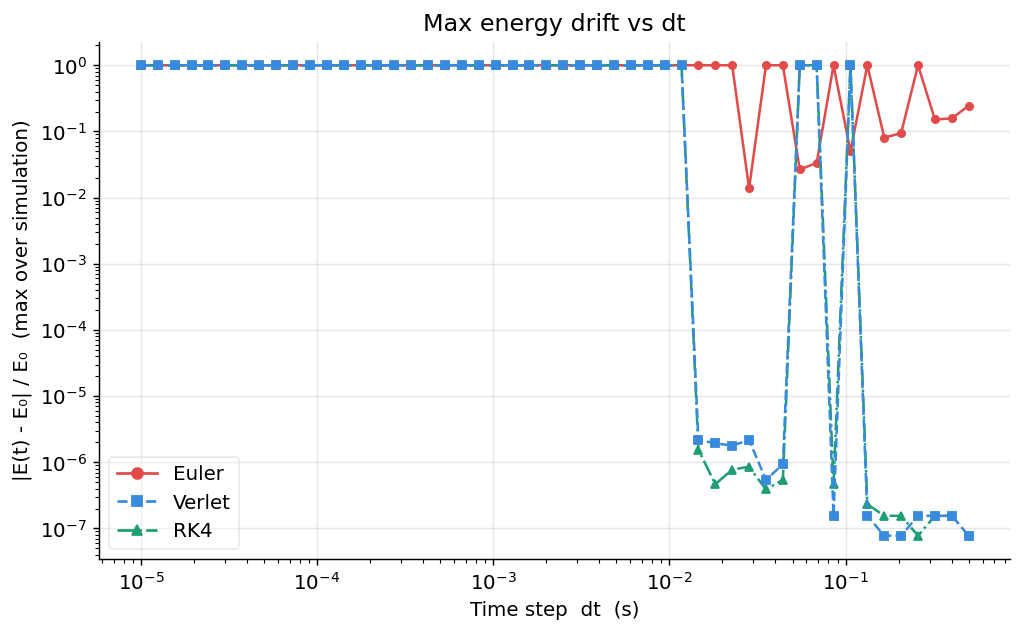

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")
    mask = grp["max_energy_drift"] > 0
    ax.loglog(grp.loc[mask, "dt"], grp.loc[mask, "max_energy_drift"],
              color=s["color"], marker=s["marker"], ls=s["ls"],
              markersize=4, linewidth=1.4)

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("|E(t) - E₀| / E₀  (max over simulation)")
ax.set_title("Max energy drift vs dt")
solver_legend(ax)
plt.tight_layout()
plt.savefig("plot_energy_drift_vs_dt.png", dpi=150)
plt.show()

# Plot 3: Cost vs precision  (ops_total vs contact_error)

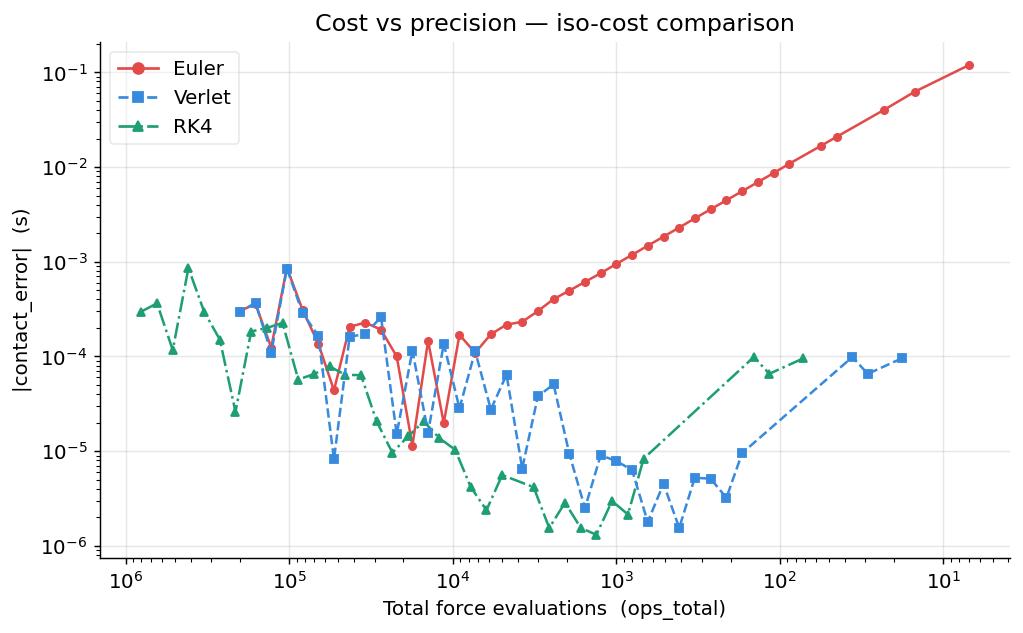

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

for solver, grp in df_valid.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("ops_total")
    mask = grp["contact_error"] > 0
    ax.loglog(grp.loc[mask, "ops_total"], grp.loc[mask, "contact_error"],
              color=s["color"], marker=s["marker"], ls=s["ls"],
              markersize=4, linewidth=1.4)

ax.set_xlabel("Total force evaluations  (ops_total)")
ax.set_ylabel("|contact_error|  (s)")
ax.set_title("Cost vs precision — iso-cost comparison")
ax.invert_xaxis()   # more ops = more expensive → right side
solver_legend(ax)
plt.tight_layout()
plt.savefig("plot_cost_vs_precision.png", dpi=150)
plt.show()

# Plot 4: CPU time vs dt

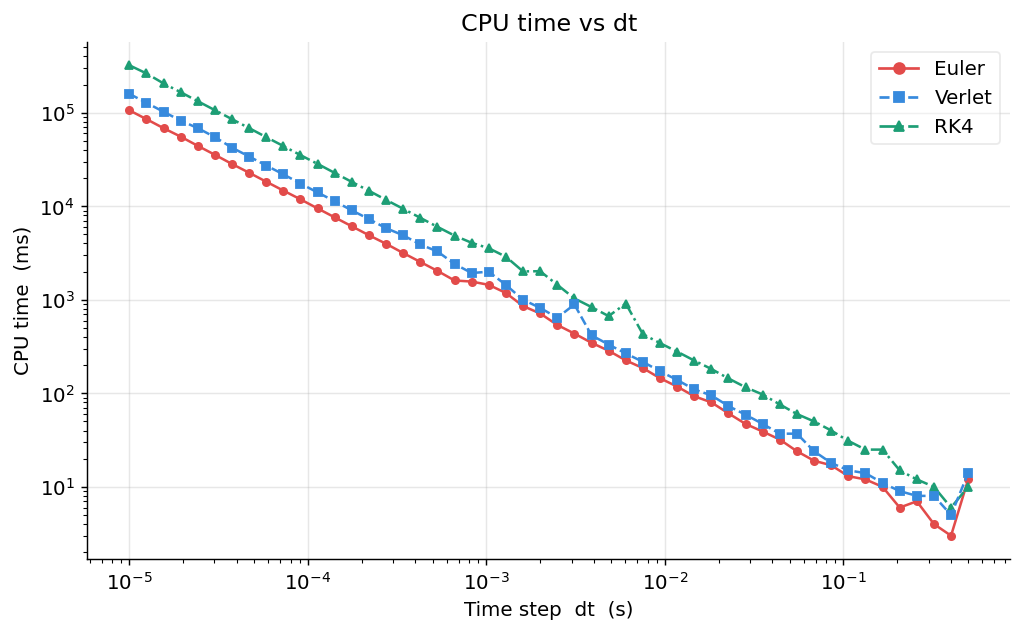

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")
    ax.loglog(grp["dt"], grp["cpu_ms"],
              color=s["color"], marker=s["marker"], ls=s["ls"],
              markersize=4, linewidth=1.4)

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("CPU time  (ms)")
ax.set_title("CPU time vs dt")
solver_legend(ax)
plt.tight_layout()
plt.savefig("plot_cpu_time.png", dpi=150)
plt.show()

# Plot 5: E(t) time series

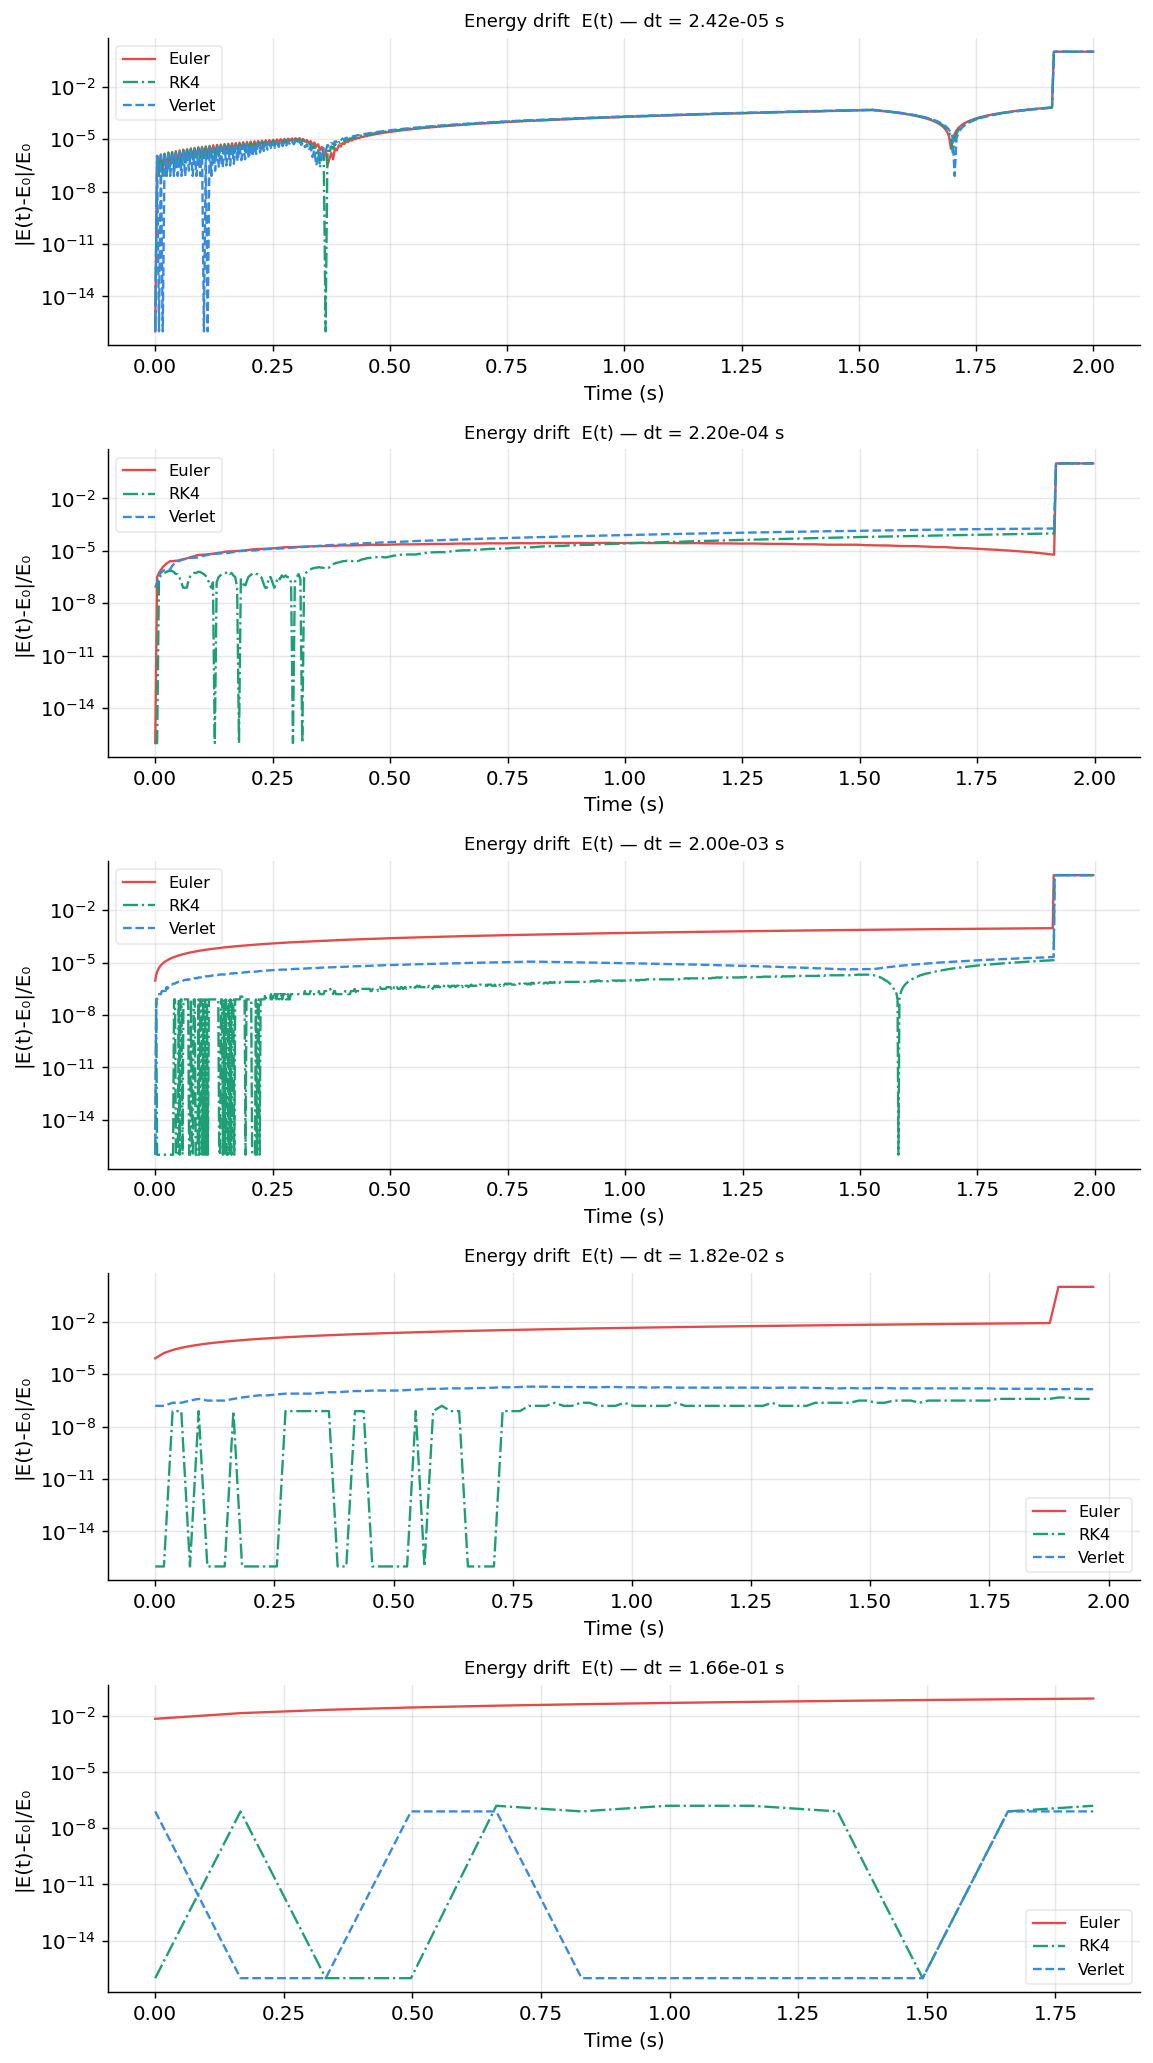

In [9]:
dt_values = sorted(ede["dt"].unique())
n_dt      = len(dt_values)
solvers   = ede["solver"].unique()

fig, axes = plt.subplots(n_dt, 1, figsize=(9, 3.2 * n_dt), sharex=False)
if n_dt == 1:
    axes = [axes]

for ax, dt_val in zip(axes, dt_values):
    subset = ede[ede["dt"] == dt_val]
    for solver, grp in subset.groupby("solver"):
        s = SOLVER_STYLE[solver]
        grp = grp.sort_values("time")
        ax.semilogy(grp["time"], grp["energy_drift"].clip(lower=1e-16),
                    color=s["color"], ls=s["ls"], linewidth=1.3, label=solver)
    ax.set_title(f"Energy drift  E(t) — dt = {dt_val:.2e} s", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("|E(t)-E₀|/E₀")
    ax.legend(fontsize=9, framealpha=0.4)

plt.tight_layout()
plt.savefig("plot_energy_time_series.png", dpi=150)
plt.show()

# Summary statistics table

In [10]:
rows = []
for solver, grp in df.groupby("solver"):
    valid = grp.dropna(subset=["contact_error"])
    n_diverged = len(grp) - len(valid)

    # Best achievable error (smallest dt)
    best_err = valid.loc[valid["contact_error"].idxmin(), "contact_error"] if len(valid) else float("nan")

    # dt threshold below which error < 1e-4 s
    below = valid[valid["contact_error"] < 1e-4]
    dt_threshold = below["dt"].max() if len(below) else float("nan")

    # Mean energy drift at smallest valid dt
    if len(valid):
        smallest_dt_row = valid.loc[valid["dt"].idxmin()]
        mean_drift = smallest_dt_row["max_energy_drift"]
        cpu_at_best = smallest_dt_row["cpu_ms"]
    else:
        mean_drift  = float("nan")
        cpu_at_best = float("nan")

    rows.append({
        "Solver":             solver,
        "Diverged (# dt)": n_diverged,
        "Best error (s)":     f"{best_err:.2e}" if not np.isnan(best_err) else "—",
        "dt for err<1e-4":    f"{dt_threshold:.2e}" if not np.isnan(dt_threshold) else "—",
        "Max energy drift":   f"{mean_drift:.2e}" if not np.isnan(mean_drift) else "—",
        "CPU @ best dt (ms)": f"{cpu_at_best:.1f}" if not np.isnan(cpu_at_best) else "—",
    })

summary = pd.DataFrame(rows).set_index("Solver")
summary

,Diverged (# dt),Best error (s),dt for err<1e-4,Max energy drift,CPU @ best dt (ms)
Solver,,,,,
Euler,9,1.14e-05,1.76e-04,1.00e+00,106263.0
RK4,14,0.00e+00,1.07e-01,1.00e+00,322008.0
Verlet,14,1.55e-06,1.07e-01,1.00e+00,159315.0


# Export all plots to a single PDF

In [11]:
from matplotlib.backends.backend_pdf import PdfPages

plot_files = [
    "plot_convergence.png",
    "plot_energy_drift_vs_dt.png",
    "plot_cost_vs_precision.png",
    "plot_cpu_time.png",
    "plot_energy_time_series.png",
]

with PdfPages("benchmark_report.pdf") as pdf:
    for path in plot_files:
        img = plt.imread(path)
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.imshow(img)
        ax.axis("off")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("PDF saved to benchmark_report.pdf")

PDF saved to benchmark_report.pdf
